In [ ]:
import tensorflow as tf #for building and training neural networks
from tensorflow.keras import layers, models #import CNN layers
import matplotlib.pyplot as plt #used to display handwritten image

In [ ]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

In [ ]:
X_train = X_train/255.0 #original pixel are 0-255, dividing by 255 changes them to 0-1
X_test = X_test/255.0

In [ ]:
X_train = X_train.reshape(-1, 28, 28, 1) #adding 1 channel for grayscale
X_test = X_test.reshape(-1, 28, 28, 1)

In [ ]:
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation = 'relu', input_shape = (28, 28, 1)),
    layers.MaxPooling2D((2,2)), #reduces image size

    layers.Conv2D(64, (3,3), activation = 'relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(), #2D to 1D

    layers.Dense(64, activation = 'relu'), #64 neurons
    layers.Dense(10, activation = 'softmax') #10 neurons, softmax gives probability for each digit
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer = 'adam', #how model should improve its weights
    loss = 'sparse_categorical_crossentropy', #measures how wrong the prediction is
    metrics = ['accuracy']
)

In [ ]:
model.fit(X_train, y_train, epochs = 5, validation_split = 0.1) #keeps 10% of training daat for validation

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 51s 29ms/step - accuracy: 0.9529 - loss: 0.1536 - val_accuracy: 0.9852 - val_loss: 0.0540
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 81s 29ms/step - accuracy: 0.9842 - loss: 0.0507 - val_accuracy: 0.9860 - val_loss: 0.0493
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 50s 30ms/step - accuracy: 0.9889 - loss: 0.0346 - val_accuracy: 0.9898 - val_loss: 0.0382
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 51s 30ms/step - accuracy: 0.9914 - loss: 0.0265 - val_accuracy: 0.9892 - val_loss: 0.0415
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 48s 28ms/step - accuracy: 0.9937 - loss: 0.0196 - val_accuracy: 0.9890 - val_loss: 0.0371


In [ ]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9915 - loss: 0.0292


In [ ]:
print("Test Accuracy: ", test_accuracy)

Test Accuracy:  0.9915000200271606


In [ ]:
prediction = model.predict(X_test[0].reshape(1, 28, 28, 1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step


In [ ]:
print("Predicted Digit: ", prediction.argmax())
print("Actual Digit: ", y_test[0])

Predicted Digit:  7
Actual Digit:  7


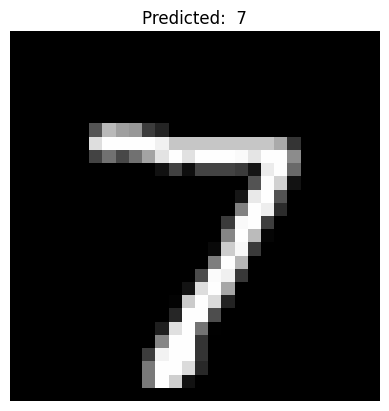

In [ ]:
plt.imshow(X_test[0].reshape(28,28), cmap = 'gray') #display the first test image
plt.title("Predicted:  " + str(prediction.argmax())) #string conversion of predicted
plt.axis('off')
plt.show()